In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r"cardio_train.csv", sep=";")

In [4]:
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


# studying fields

In [5]:
# age is in days
# height is in cm
# weight is in kg
# ap_hi is pressure in your blood vessels when heart beats, higher values mean the heart is pushing harder, increases the risk.
# ap_lo is the pressure in your blood vessels when heart is resting between beats, high diastolic pressure also signals hypertension, unusually low values indicates risk.
# cholesterol level is amount of fat-like substance in blood, too much can block blood vessels, 1 = normal 2 = higher than normal 3 = much higher than normal high cholesterol can lead to risk, increases chance of heart attack or stroke.
# gluc is amount of sugar in your blood, 1 = normal 2 = higher than normal 3 = much higher than normal high glucose can indicate diabetes which strongly affects heart
# smoke 0 not smoking 1 not smoking
# same for alco, active, and cardio, gender is 1 or 2

# Data Cleaning and Feature Engineering

Dropping id column as it is just index and of no use in prediction

In [6]:
if "id" in df.columns:
    df.drop("id", axis=1, inplace=True)

df.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,17474,1,156,56.0,100,60,1,1,0,0,0,0


Checking missing value and duplicate value

In [7]:
null_counts = df.isnull().sum()
null_counts

age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

In [8]:
duplicate_count = df.duplicated().sum()
duplicate_count

np.int64(24)

Convert age to years

In [9]:
df['age_years'] = (df['age'] / 365.25).round().astype(int)
df[["age", "age_years"]].head()

,age,age_years
0,18393,50
1,20228,55
2,18857,52
3,17623,48
4,17474,48


Statistical Summary

In [10]:
df.describe().T # transpose matrix

,count,mean,std,min,25%,50%,75%,max
age,70000.0,19468.865814,2467.251667,10798.0,17664.0,19703.0,21327.0,23713.0
gender,70000.0,1.349571,0.476838,1.0,1.0,1.0,2.0,2.0
height,70000.0,164.359229,8.210126,55.0,159.0,165.0,170.0,250.0
weight,70000.0,74.205690,14.395757,10.0,65.0,72.0,82.0,200.0
ap_hi,70000.0,128.817286,154.011419,-150.0,120.0,120.0,140.0,16020.0
ap_lo,70000.0,96.630414,188.472530,-70.0,80.0,80.0,90.0,11000.0
cholesterol,70000.0,1.366871,0.680250,1.0,1.0,1.0,2.0,3.0
gluc,70000.0,1.226457,0.572270,1.0,1.0,1.0,1.0,3.0
smoke,70000.0,0.088129,0.283484,0.0,0.0,0.0,0.0,1.0
alco,70000.0,0.053771,0.225568,0.0,0.0,0.0,0.0,1.0


# Visualisations

Checking whether dataset is balanced or not

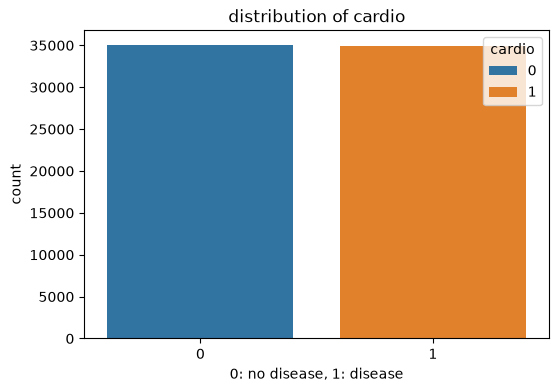

cardio
0    0.5003
1    0.4997
Name: proportion, dtype: float64

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x="cardio", data=df, hue="cardio")
plt.title("distribution of cardio")
plt.xlabel("0: no disease, 1: disease")
plt.ylabel("count")
plt.show()
df['cardio'].value_counts(normalize=True)

In [12]:
# there are almost equal people with disease and no disease

Age distribution and relation with disease

Text(0.5, 0, 'Age in years')

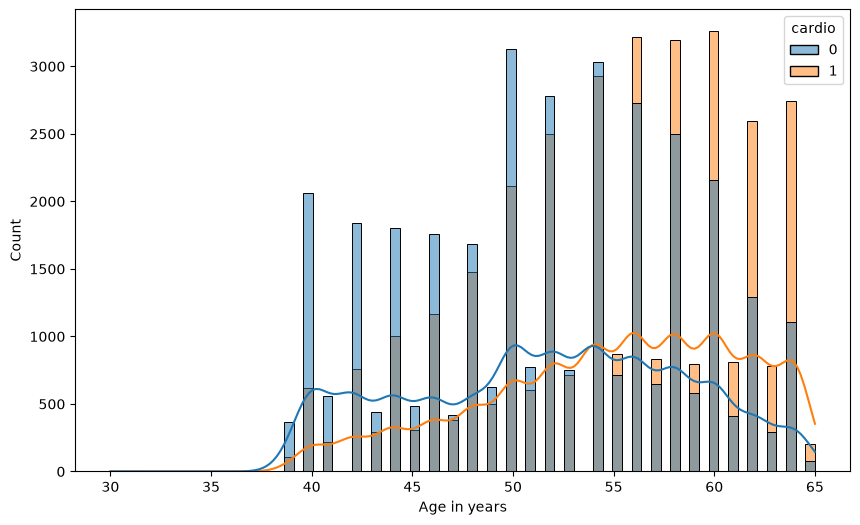

In [13]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='age_years', kde=True, hue="cardio") #kde generates curve 
plt.xlabel("Age in years")

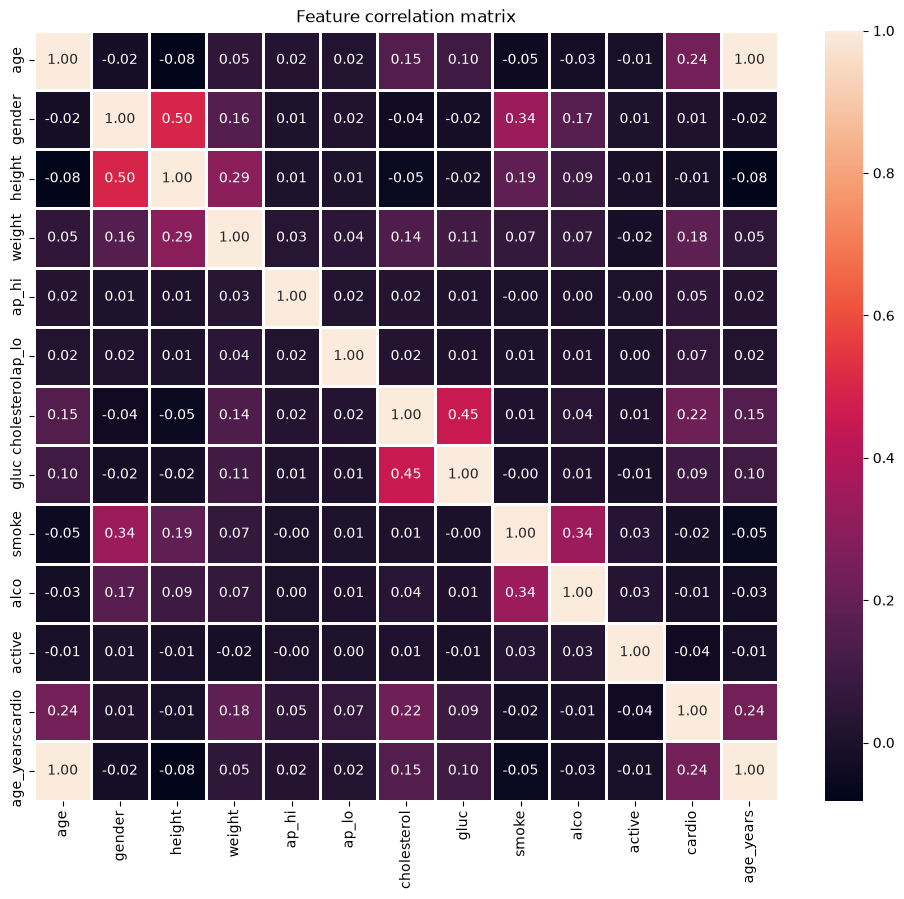

In [14]:
# correlation between all fields
plt.figure(figsize=(12, 10))
corr_matrix = df.corr()

corr_matrix
sns.heatmap(corr_matrix, annot=True, fmt=".2f", linewidths=1)
plt.title("Feature correlation matrix")
plt.show()

checking how cholestrol, glucose and smoking, alcohol and lifestyle affects

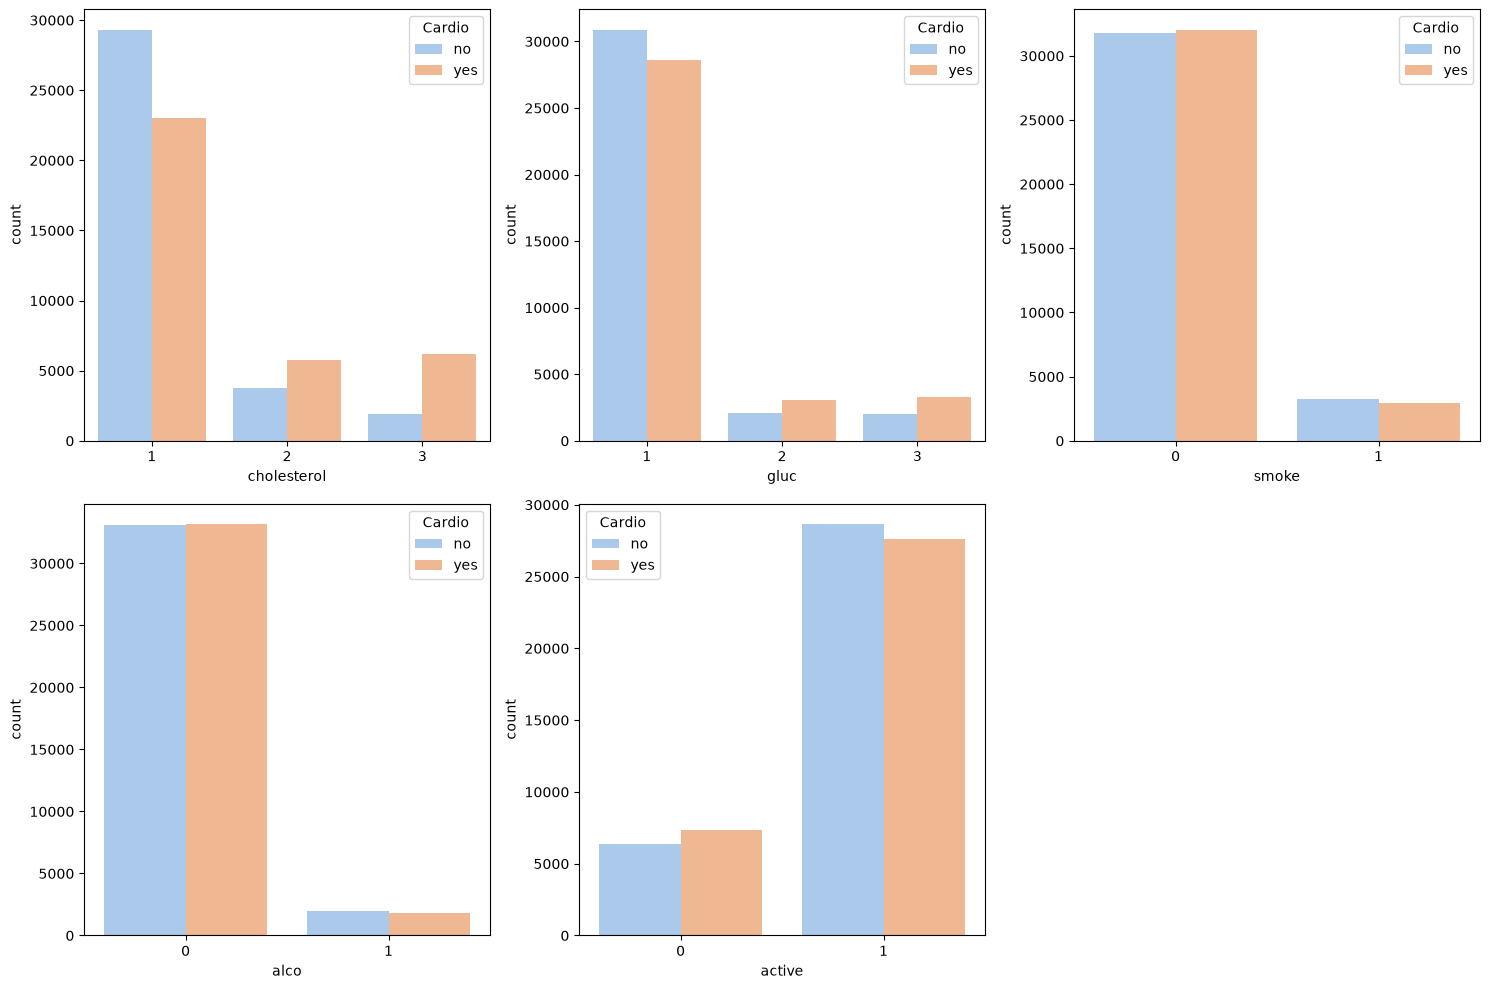

In [15]:
categorical_features = ["cholesterol", "gluc", "smoke", "alco", "active"]

plt.figure(figsize = (15, 10))

for i, feature in enumerate(categorical_features):
    plt.subplot(2, 3, i+1)
    sns.countplot(x=feature, hue="cardio", data=df, palette="pastel")
    plt.xlabel(feature)
    plt.ylabel("count")
    plt.legend(title="Cardio", labels=["no", "yes"])
plt.tight_layout()
plt.show()

In [16]:
# as level of cholestrol and gluc increase ratio of sick people increases
# active people have low ratio of disease compared to not active

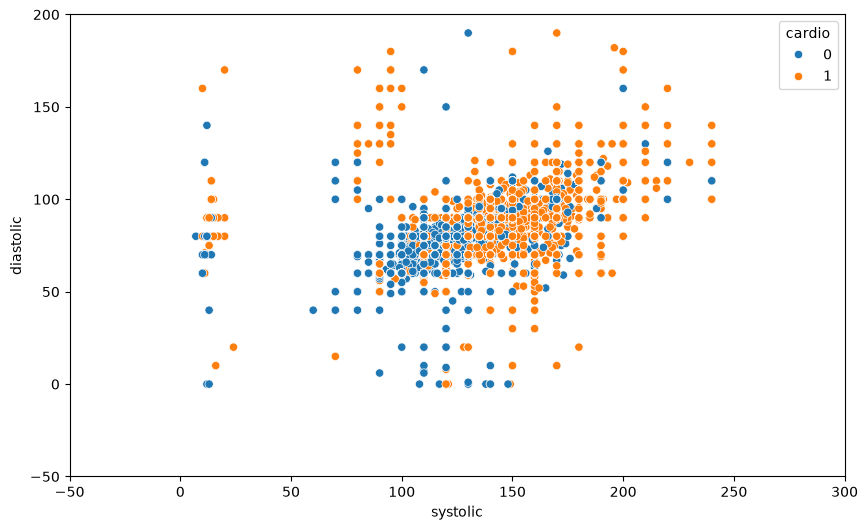

In [17]:
# checking impossible values, ap_hi must be higher than ap_lo
plt.figure(figsize=(10, 6))
sns.scatterplot(x="ap_hi", y="ap_lo", hue="cardio", data=df, alpha=1)

plt.xlabel("systolic")
plt.ylabel("diastolic")

plt.xlim(-50, 300)
plt.ylim(-50, 200)
plt.show()
impossible_bp = df[(df["ap_hi"] < df["ap_lo"]) | (df["ap_hi"] < 0) | (df["ap_lo"] < 0)]


calculating bmi for obesity

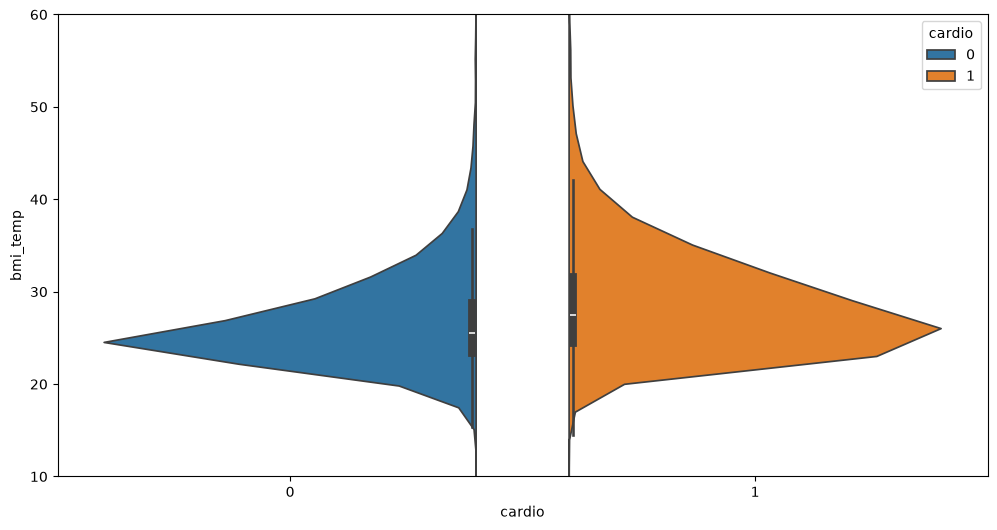

25.476660092044707
25.476660092044707


In [19]:
df["bmi_temp"] = df["weight"] / ((df["height"] / 100) ** 2) # height in cm
plt.figure(figsize=(12, 6))
sns.violinplot(x="cardio", y="bmi_temp", data=df, hue="cardio", split=True)
# probability density = violin plot
plt.ylim(10, 60)
plt.show()
# 0 = healthy, 1 = disease
bmi_healthy_median = df[df['cardio'] == 0]["bmi_temp"].median()
print(bmi_healthy_median)
bmi_sick_median = df[df['cardio'] == 1]["bmi_temp"].median()
print(bmi_healthy_median)

outlier visualization for height and width

Text(0.5, 1.0, 'weight distribution')

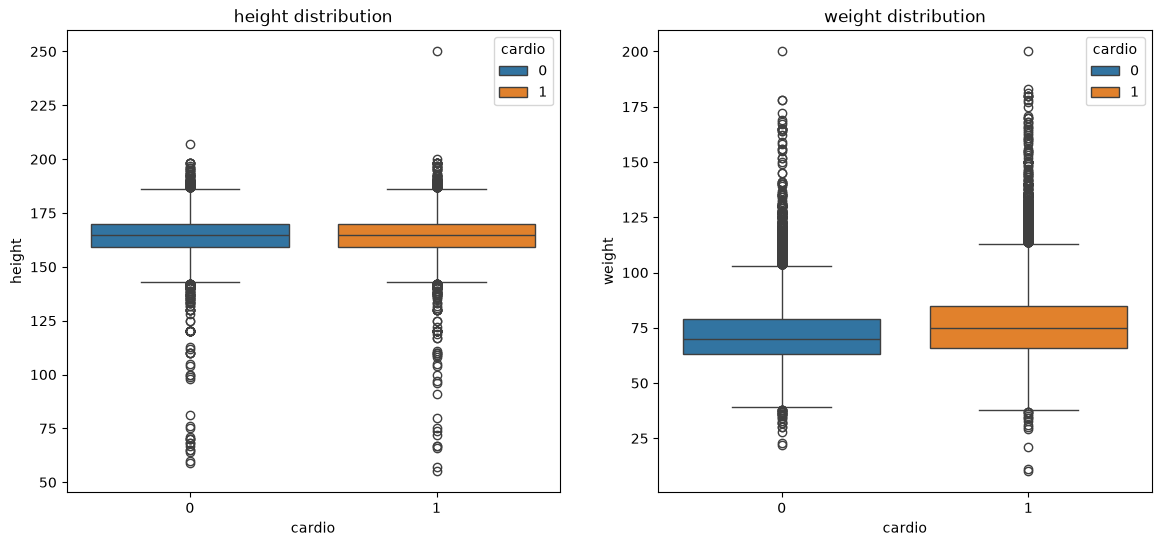

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.boxplot(x="cardio", y="height", data=df, ax=axes[0], hue="cardio")
axes[0].set_title("height distribution")
sns.boxplot(x="cardio", y="weight", data=df, ax=axes[1], hue="cardio")
axes[1].set_title("weight distribution")


relation between age weight and bp

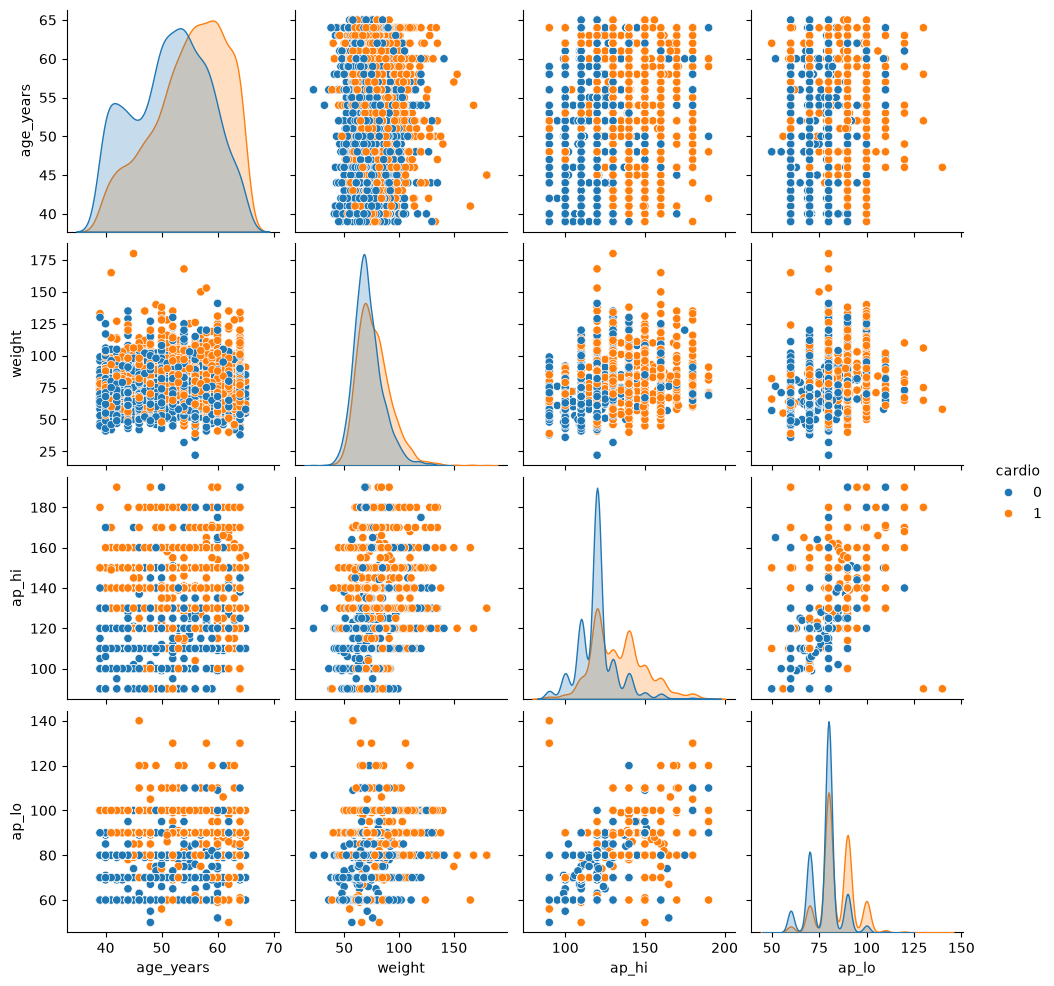

In [25]:
plot_df = df[(df['ap_hi'] < 200 ) & (df['ap_lo'] < 150) & (df['ap_hi'] > 80) & (df['ap_lo'] > 40)].sample(5000, random_state=42)
sns.pairplot(plot_df, vars=["age_years", "weight", "ap_hi", "ap_lo"], hue="cardio", plot_kws={"alpha": 1})